## Welcome to The Disco Biscuits Analysis Project

The Disco Biscuits are a "trance-fusion" Jam Band that was formed in 1995, heralding from Philladelphia Pennsylvania in the United States.  Their unique sound and catalog has evolved over the nearly 30 years of their history, but one constant throughout this period is that they continue to push the envelope of improvisational music.  One of the key elements that sets the Disco Biscuits apart is ther experimentation with their song catalog and finding new ways to keep their fans on their toes.  The band effortlessly blends one song into another, creating what are known as "segues" (typically denoted with a ">" in the track listing of a show) where the band improvises or "jams" between songs, creating a completely new sound on the fly, which may never be heard again after that show.  Songs are often rearranged into unique renditions, such as "inverted" songs (where a song is broken up and the "ending" section is played first, then the band jams into the "beginning" section of the song), or "dyslexic" versions (where the song is again broken up, but entirely different songs are inserted into the middle, and the band eventually returns to finish the song that was started earlier).  "Palindrome" sets are created when the band plays a series of songs that are split up and revisited in order to have the setlist read the same forwards and backwards (e.g. Overture > Basis for a Day > Vassillios > Basis for a Day > Overture).

#### Data Source
The dataset in this project comes from a fan-created website, [www.discobiscuits.net](www.discobiscuits.net), (which I have contributed to over the years) that catalogs the entire history of the band, including all setlists, venues, and key info and annotations about different renditions and versions of the songs.  The rich historical information available on this site, along with the constant evolution of the band and its catalog, lends itself perfectly to an investigative project that allows us to explore the music of this band over the decades, which continues to draw fans to live shows that are always unique and mind-blowing.

I reached out to the discobiscuits.net site maintainers and requested a CSV export of some of the key tables that makes up the Postgresql database backing the site.  These tables inclued the song catalog (songa.csv), information about the venues they have played (venues.csv), the show listing (shows.csv), the order of songs within particular shows (tracks.csv), and notes about the composition and unique attributes of individual versions of a song (annotation.csv).  As this data comes from a relational database, there are foreign keys linking records from one table to records on another (e.g. the tracks table has a foreign key to the songs and shows tables, which in turn has a foreign key to the venues table).


In addition, a list of US states and regions was obtained from [GitHub user @cphalpert](https://github.com/cphalpert/census-regions/blob/master/us%20census%20bureau%20regions%20and%20divisions.csv) - the data from this file originally came from the US Census Bureau website as a [PDF file](https://www2.census.gov/geo/pdfs/maps-data/maps/reference/us_regdiv.pdf).  This data is publicly available, but was not easily retrieved via the US Census Bureau's API, nor was it found in a concise manner via many other API sources I tried.

#### Notebook Setup
This notebook assumes the user has installed the anaconda package, which contains a set of included packages.  At a minimum, the python environment must provide the following packages:
- pandas (used for processing the CSV files)
- mathplotlib (used for plotting line graphs)
- plotly (used for state heatmaps)

## Data import and processing

In [181]:
# we will use pandas to load the CSV files and preview the dataframes
import pandas as pd

# Load the CSV files
venues_df = pd.read_csv('data/venues.csv')
bands_df = pd.read_csv('data/bands.csv')
authors_df = pd.read_csv('data/authors.csv')
songs_df = pd.read_csv('data/songs.csv')
shows_df = pd.read_csv('data/shows.csv')
tracks_df = pd.read_csv('data/tracks.csv')
annotations_df = pd.read_csv('data/annotations.csv')
states_df = pd.read_csv('data/states-regions.csv')

The venues data contains information about each venue the band has played, including its name and city/state.

Let's drop some unimportant columns from this dataset which are not relevant to our project, and preview this table's data.

In [182]:
# remove unnecessary columns by preforming an inplace drop
venues_df.drop(columns=['slug', 'street', 'latitude', 'longitude', 'phone', 'website', 'created_at', 'updated_at'], axis=1, inplace=True)
venues_df_preview = venues_df.head()
venues_df_preview

,id,name,city,state,country,postal_code,legacy_id,times_played
0,49ce1870-7f87-4977-9f69-f844d964e135,Monopole,Plattsburgh,NY,NaN,NaN,NaN,0
1,1c9aeebd-707c-4d30-9b00-83fef9c841eb,"Campus Pub, SUNY Binghamton",Binghamton,NY,NaN,NaN,58.0,1
2,f479d7ba-e37a-4dfa-880a-7cdf38278f13,"College Green, Brown University",Providence,RI,NaN,NaN,77.0,1
3,2c52099e-f5a0-44fc-8c5b-d87734942e73,3:19 Club,Chico,CA,NaN,NaN,3.0,1
4,8c3e9a81-d10e-46de-835a-67050a55bf40,Cabaloosa,New Paltz,NY,NaN,NaN,49.0,4


The Songs dataset contains information about each song, including its title, number of times played, when it was last played, and how many times per year it was played.

We can get rid of some unimportant columns that are not relevant to this project.

In [183]:
songs_df.drop(columns=['lyrics', 'tabs', 'slug', 'legacy_id', 'legacy_author', 'notes', 'legacy_abbr', 'history', 'featured_lyric', 'guitar_tabs_url', 'created_at', 'updated_at'], axis=1, inplace=True)
songs_df_preview = songs_df.head()
songs_df_preview

,id,title,cover,author_id,times_played,date_last_played,yearly_play_data,longest_gaps_data,most_common_year,least_common_year
0,d9fe0cfe-dd11-4d8a-983f-a3c4e27bf01a,Take a Bow,True,0741948c-afa5-4f19-bb97-126844a6fa0a,2,2007-08-30,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""0"": {""date"": ""2007-08-18"", ""previous"": null,...",2007,2007.0
1,26e4e607-5b8c-4f01-914a-59c5f2e0fda1,She's A Bad Mama Jama,True,198854b8-6151-4ac8-8a2d-0ebc633d59ff,1,2016-03-25,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""0"": {""date"": ""2016-03-25"", ""previous"": null,...",2016,2016.0
2,a2271b6e-292b-43a4-a16f-6c880c77ad09,Her Majesty,True,4c05e770-de89-4034-970d-7841d064b9e6,2,1995-12-02,"{""1995"": 2, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""0"": {""date"": ""1995-11-09"", ""previous"": null,...",1995,1995.0
3,00599772-dc5b-4e4a-85ae-f3ad79ed0896,Bad Love,True,9086752c-7d9a-4805-8a0a-9084c69282c5,1,1999-03-06,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""0"": {""date"": ""1999-03-06"", ""previous"": null,...",1999,1999.0
4,fecddfb7-8f2a-4129-b6b2-0dfdfd884113,I Wanna Be Sedated,True,67da6e12-008c-476e-bfc2-77da47eeee1a,4,2007-10-24,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""0"": {""date"": ""2007-08-15"", ""previous"": null,...",2007,2007.0


If we are specifically interested in songs that are NOT covers of songs written by other bands, we can create a filtered dataframe containing only original songs:

In [184]:
original_songs_df = songs_df[songs_df['cover'] == False]
original_songs_df_preview = original_songs_df.head()
original_songs_df_preview

,id,title,cover,author_id,times_played,date_last_played,yearly_play_data,longest_gaps_data,most_common_year,least_common_year
7,d90fb6b4-270f-4307-9cd8-c21fa23b2c18,Humuhumunukunukuapua'a,False,2c0efbda-2ac6-4789-95a4-de69013a617b,91,2024-04-05,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""35"": {""date"": ""2009-10-10"", ""previous"": ""200...",2002,2005.0
8,9175f0b7-7768-4a78-9eb8-c3d1ce51bb09,Camera B,False,4338604b-38e0-432c-855b-bcd9091d4409,17,2006-11-14,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""8"": {""date"": ""2006-11-08"", ""previous"": ""2006...",2006,2005.0
13,7e7124e2-22bf-4424-9c14-08cd200822b4,Stars in the Sky,False,e29db38d-5b63-4e2c-b5bc-8f4ed3fe1c64,8,2024-11-13,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""10"": {""date"": ""2024-07-13"", ""previous"": ""202...",2024,2019.0
18,c6c86090-0e1d-4e07-815a-3f6f9f0fa26e,The Devil's Waltz,False,7a01161d-ab82-40e5-99a1-49945cf0be96,133,2021-06-26,"{""1995"": 0, ""1996"": 5, ""1997"": 39, ""1998"": 38,...","{""62"": {""date"": ""2016-06-02"", ""previous"": ""201...",1997,2012.0
19,259c5665-c6b3-4582-823e-4c3e735c031c,Salute To Sammy,False,e29db38d-5b63-4e2c-b5bc-8f4ed3fe1c64,1,2005-08-27,"{""1995"": 0, ""1996"": 0, ""1997"": 0, ""1998"": 0, ""...","{""0"": {""date"": ""2005-08-27"", ""previous"": null,...",2005,2005.0


The shows table includes information about individual shows.  To make things easier later, we will add an additional "year" column, which will contain just the year, obtained by parsing the date column and extracting the year.

In [185]:
shows_df.drop(columns=['slug', 'notes', 'legacy_id', 'created_at', 'updated_at', 'relisten_url', 'show_photos_count', 'show_youtubes_count', 'reviews_count'], axis=1, inplace=True)
# Ensure the 'date' column in shows_df is a datetime type
shows_df['date'] = pd.to_datetime(shows_df['date'], errors='coerce')
# Extract the year from the show date
shows_df['year'] = shows_df['date'].dt.year
shows_df_preview = shows_df.head()
shows_df_preview

,id,date,venue_id,band_id,likes_count,average_rating,year
0,73e7ad08-2e2c-4a83-a768-aaba6e004716,1998-05-23,54becbfa-b56c-452d-803e-0201fb375d2e,db7f2c5d-2727-41fd-bd6f-e91c74164f09,0,0.000000,1998
1,25bcc399-ce8f-4683-a2a6-5486eeba347d,2021-07-09,2b839f0d-5ce0-402a-a7ae-aee8968dc3e9,db7f2c5d-2727-41fd-bd6f-e91c74164f09,0,4.419355,2021
2,77a948be-4d60-4bc4-8ddc-688e367039b1,1999-02-05,023caca8-36d3-42ef-adbe-dc5471812061,db7f2c5d-2727-41fd-bd6f-e91c74164f09,0,3.500000,1999
3,c583ecd1-8fb4-4c65-9558-51f3f7a8558a,2021-05-18,772346af-6a44-47b2-980d-aba4db9f114f,db7f2c5d-2727-41fd-bd6f-e91c74164f09,0,3.913043,2021
4,99ed5f5e-e062-4fe3-a4e1-521d11a8124c,2021-11-27,8dfeef2a-b9f9-4b71-8346-ebbd242f31af,db7f2c5d-2727-41fd-bd6f-e91c74164f09,0,4.320000,2021


The tracks table provides data about each time a song was played, along with its position in the set, and what track came before/after this track.

In [186]:
tracks_df.drop(columns=['slug', 'created_at', 'updated_at', ], axis=1, inplace=True)
tracks_df_preview = tracks_df.head()
tracks_df_preview

,id,show_id,song_id,set,position,segue,likes_count,note,all_timer,previous_track_id,next_track_id,average_rating
0,70848664-b33f-46cc-a7b3-f3b5688ee3f3,5f40bdf9-32ec-4061-9b29-b5341e32eefe,e5a0b3a1-5e2b-409c-9b5c-0beafff15c62,S1,2,NaN,0,NaN,False,a1528807-d341-4cad-af3d-e9385fab7f5b,6915b2c5-9ff5-4b5d-b731-32aeee1f4fe5,0.0
1,f755b828-f90e-4737-838b-56f32f4d5776,5f40bdf9-32ec-4061-9b29-b5341e32eefe,f98418ae-748e-4459-8a5c-2b5fefa4c81d,S1,4,NaN,0,NaN,False,6915b2c5-9ff5-4b5d-b731-32aeee1f4fe5,9875a257-ba2b-4f98-88bf-7696d6b7bee9,0.0
2,9875a257-ba2b-4f98-88bf-7696d6b7bee9,5f40bdf9-32ec-4061-9b29-b5341e32eefe,2d5b75b8-339a-4af1-b136-dc6857d0bc54,S1,5,NaN,0,NaN,False,f755b828-f90e-4737-838b-56f32f4d5776,f43b0ffa-22f1-4413-89ed-f3b07868b3e0,0.0
3,f43b0ffa-22f1-4413-89ed-f3b07868b3e0,5f40bdf9-32ec-4061-9b29-b5341e32eefe,5147e937-0370-4802-a690-2a54e3a1d77e,S1,6,NaN,0,NaN,False,9875a257-ba2b-4f98-88bf-7696d6b7bee9,a96b2e47-b6e1-4f61-b069-2328ecfef3b5,0.0
4,278fbf8d-af97-43df-916a-4e259e2774b8,5f40bdf9-32ec-4061-9b29-b5341e32eefe,31d0c9ec-224a-426d-92af-daf8fe81e88f,S1,8,NaN,0,NaN,False,a96b2e47-b6e1-4f61-b069-2328ecfef3b5,d54a92c0-7120-4025-9a29-b10531abc7dc,0.0


The annotations table contains information about individual tracks, with notes about how the song was played in that particular instance.  This gives us details about whether it was inverted, dyslexic, as well as other arbitrary facts such as "first time played" or indicating a guest performer, etc.

In [187]:
annotations_df.drop(columns=['created_at', 'updated_at', ], axis=1, inplace=True)
annotations_df_preview = annotations_df.head()
annotations_df_preview

,id,track_id,desc
0,01476ed6-bd97-4c13-8698-4a75d90007b3,47377c59-2bce-4558-a0d4-906777a95470,With 'Slipknot!' and 'Disco Bisquick' teases.
1,8c4d8cb5-19cf-4fc0-bebc-d450bd819529,104b4572-a59c-49d1-afba-e99343513f36,No lyrics but there's some distinct Barfly jam...
2,15b17451-5b61-4720-b8ec-46822583a374,85b15ff6-591a-4404-989b-20338151ffcd,With Elliot Levin on saxophone.
3,ba52d549-0d20-415e-b2ce-9c738c969e6d,c6b0ebdd-9a12-464a-a7dc-5b40502c3397,With Elliot Levin on saxophone.
4,63eaf8bc-9a91-4516-b4be-2ab824d91b68,f7330756-4cfa-4b8d-930b-5f45c627f9ab,With Elliot Levin on saxophone.


## Analysis

Now we will begin to investigate the datasets to glean interesting information from them.

### Most commonly played songs
First, let's begin by taking a look at the top 20 most commonly played songs of all time.

In [490]:
most_played_songs = songs_df[['title', 'times_played']].sort_values(by='times_played', ascending=False).head(20)
most_played_songs.rename(columns={'title': 'Song Title', 'times_played': 'Times Played'}, inplace=True)
most_played_songs

,Song Title,Times Played
219,I-Man,367
427,Morph Dusseldorf,359
211,Helicopters,335
207,Basis For A Day,328
467,M.E.M.P.H.I.S.,310
382,Shem-Rah Boo,308
394,Mindless Dribble,291
100,Aceetobee,288
487,Above The Waves,282
480,Little Shimmy In A Conga Line,280


### Common set openers
Now let's look at what songs were most commonly used to open a particular set.  The tracks table data indicates the set number (e.g. S1, S2, S3, or E1 to indicate the Encore), as well as the track's position in the set.

In [510]:
# join the tracks and songs dataframes on the song_id column to get the song title for each track
tracks_songs_merged = tracks_df.merge(songs_df, left_on='song_id', right_on='id', how='inner')

# we are interested in all the tracks where the position is 1, which means they are the opening songs
opening_songs = tracks_songs_merged[tracks_songs_merged['position'] == 1]

# Find the most frequent song opening each set (S1, S2, S3, etc.)
most_frequent_openers = (
    opening_songs.groupby('set', as_index=False)['title']
    # We specify the aggregation function to apply the lambda function to the grouped
    # data to find the mode (most frequently occurring value) and number of times it occurred.
    # In case there is a tie, we break it by selecting the first value (.iloc[0])
    .agg([
        ('most_frequent_opener', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        # open_count is the number of times the most frequent opener was played
        ('open_count', lambda x: x.value_counts().iloc[0] if not x.mode().empty else 0)
    ])
)

# re-order the output to match the desired order (sets first, then encores)
desired_order = ['S1', 'S2', 'S3', 'S4', 'E1', 'E2']
most_frequent_openers_reordered = most_frequent_openers.set_index('set').loc[desired_order].reset_index()
most_frequent_openers_reordered.rename(columns={'most_frequent_opener': 'Most Frequent Opener', 'open_count': 'Count'}, inplace=True)
most_frequent_openers_reordered

,set,Most Frequent Opener,Count
0,S1,Jam,66
1,S2,Jam,47
2,S3,Mindless Dribble,5
3,S4,Magellan,1
4,E1,Home Again,46
5,E2,Above The Waves,1


As seen in the output above, the most common set 1 and set 2 opener is listed as "Jam", however this is not an actual song.  This means the band started the set by improvising together for a while, before eventually transitioning into the first song.  Let's exclude these from the output to get more meaningful data about which song actually came first in the set.

In [511]:
# Exclude the "Jam" track from the data
filtered_opening_songs = opening_songs[opening_songs['title'] != 'Jam']

# Find the most frequent song opening each set again.
most_frequent_openers_filtered = (
    filtered_opening_songs.groupby('set', as_index=False)['title']
    # We specify the aggregation function to apply the lambda function to the grouped
    # data to find the mode (most frequently occurring value) and number of times it occurred.
    # In case there is a tie, we break it by selecting the first value (.iloc[0])
    .agg([
        ('most_frequent_opener', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        # open_count is the number of times the most frequent opener was played
        ('open_count', lambda x: x.value_counts().iloc[0] if not x.mode().empty else 0)
    ])
)

# re-order the output to match the desired order (sets first, then encores)
desired_order = ['S1', 'S2', 'S3', 'S4', 'E1', 'E2']
most_frequent_openers_reordered = most_frequent_openers_filtered.set_index('set').loc[desired_order].reset_index()
most_frequent_openers_reordered.rename(columns={'most_frequent_opener': 'Most Frequent Opener', 'open_count': 'Count'}, inplace=True)
most_frequent_openers_reordered

,set,Most Frequent Opener,Count
0,S1,M.E.M.P.H.I.S.,55
1,S2,Mindless Dribble,38
2,S3,Mindless Dribble,5
3,S4,Magellan,1
4,E1,Home Again,46
5,E2,Above The Waves,1


### Commonly "inverted" songs
Now we'd like to analyze the songs that have been "inverted" most often.

In [529]:
# Filter annotations to include only those with "inverted" in the desc column (case-insensitive, ignoring errors if there is no data - NaN)
inverted_annotations = annotations_df[
    annotations_df['desc'].str.contains('inverted', case=False, na=False)
]

# Join the inverted annotations with the tracks data to get song IDs
inverted_tracks = inverted_annotations.merge(tracks_df, left_on='track_id', right_on='id', how='inner')

# Join with the songs data to get song titles
inverted_songs = inverted_tracks.merge(songs_df, left_on='song_id', right_on='id', how='inner')

# Count how many times each song has been "inverted"
inverted_song_counts = (
    inverted_songs.groupby('title', as_index=False)
    .size()
    .rename(columns={'title': 'song', 'size': 'inverted_count'})
    .sort_values(by='inverted_count', ascending=False)
)
inverted_song_counts.rename(columns={'song': 'Song Title', 'inverted_count': 'Inverted Count'}, inplace=True)
inverted_song_counts.head(20)

,Song Title,Inverted Count
2,Above The Waves,103
16,Confrontation,84
6,And the Ladies Were the Rest of the Night,81
18,Crickets,81
3,Abraxas,80
34,Little Betty Boop,47
53,Reactor,31
28,Humuhumunukunukuapua'a,31
70,The Overture,31
59,Shelby Rose,30


### Commonly "dyslexic" songs
Similarly, let's look at the songs with the highest frequency of being played "dyslexic" (i.e., songs that are inverted, but have other distinct songs inserted between the inverted portions of the song).

In [546]:
# Filter annotations to include only those with "dyslexic" in the desc column (case-insensitive, ignoring errors if there is no data - NaN)
dyslexic_annotations = annotations_df[
    annotations_df['desc'].str.contains('dyslexic', case=False, na=False)
]

# Join the dyslexic annotations with the tracks data to get song IDs
dyslexic_tracks = dyslexic_annotations.merge(tracks_df, left_on='track_id', right_on='id', how='inner')

# Join with the songs data to get song titles
dyslexic_songs = dyslexic_tracks.merge(songs_df, left_on='song_id', right_on='id', how='inner')

# Count how many times each song has been "inverted"
dyslexic_song_counts = (
    dyslexic_songs.groupby('title', as_index=False)
    .size()
    .rename(columns={'title': 'song', 'size': 'dyslexic_count'})
    .sort_values(by='dyslexic_count', ascending=False)
)
dyslexic_song_counts.rename(columns={'song': 'Song Title', 'dyslexic_count': 'Dyslexic Count'}, inplace=True)
dyslexic_song_counts.head(20)

,Song Title,Dyslexic Count
30,Morph Dusseldorf,22
31,Munchkin Invasion,21
38,Save The Robots,21
44,Svenghali,18
11,Confrontation,18
9,Bernstein and Chasnoff,17
4,And the Ladies Were the Rest of the Night,16
12,Crickets,15
3,Above The Waves,15
26,Little Shimmy In A Conga Line,15


### Shows where a single song occurs >= 4 times
Another interesting analysis is to look at shows where a single song appears many times.  This often indicates a unique situation where the band weaves in and out of a song, seamlessly blending multiple songs together in a way that blurs the line of what songs are even being played, leaving fans with jaws on the floor, wondering how it is een possible.

In [ ]:
# Merge track, show, and song data
tracks_with_shows_songs = tracks_df.merge(shows_df, left_on='show_id', right_on='id', how='inner').merge(
    songs_df, left_on='song_id', right_on='id', how='inner'
)

# we define a function that will be used to concatenate the track titles, including the "segue" column between titles to
# indicate transitions between songs
def concatenate_tracks(group):
    # Define the order for sets, which will be used for sorting the tracks so they
    # appear in the correct order in the concatenated list
    set_order = {'S1': 1, 'S2': 2, 'S3': 3, 'S4': 4, 'E1': 5, 'E2': 6}
    
    # Sort by `set` (using defined order) and `position` within each set
    group_sorted = group.sort_values(
        by=['set', 'position'],
        key=lambda col: col.map(set_order).fillna(float('inf')) if col.name == 'set' else col
    )
    
    # Concatenate track titles using the "segue" column or a comma
    return ''.join(
        # Include the title and segue (if available) for each track, otherwie use a comma to indicate the music stopped
        # between songs
        f"{row['title']} {row['segue'] if pd.notna(row['segue']) and row['segue'].strip() != '' else ','} "
        for _, row in group_sorted.iterrows()
    ).rstrip(', ') # remove the last comma on the end track

# Create a concatenated track list for each show.  This dataframe will be used later by other code blocks
track_lists = (
    tracks_with_shows_songs.groupby('show_id')
    # include_groups=False to avoid deprecation warning about including the group key in the result.  See https://stackoverflow.com/a/78100669
    .apply(concatenate_tracks, include_groups=False)
    .reset_index(name='Track List')
)

# Group by show_id and song_id to count occurrences
song_occurrences = tracks_with_shows_songs.groupby(['show_id', 'song_id']).size().reset_index(name='count')

# Filter for songs that appear at least 3 times in the same show and include details
songs_with_details = song_occurrences[song_occurrences['count'] >= 4].merge(
    songs_df, left_on='song_id', right_on='id', how='inner'
).merge(
    shows_df, left_on='show_id', right_on='id', how='inner'
)

# Merge the track list into the filtered results
songs_with_details = songs_with_details.merge(track_lists, on='show_id', how='left')

# Select and rename relevant columns
songs_with_details = songs_with_details[['title', 'date', 'count', 'Track List']]
songs_with_details.rename(columns={'title': 'Song Title', 'date': 'Show Date', 'count': 'Count'}, inplace=True)

# Sort by show date
songs_with_details = songs_with_details.sort_values(by='Show Date')
pd.set_option('display.max_colwidth', None)
songs_with_details

,Song Title,Show Date,Count,Track List
0,I-Man,1997-10-29,4,"Shem-Rah Boo > Down To The Bottom , My Lady Survives , Vassillios , Trooper McCue > Soul Sacrifice > Trooper McCue , Nughuffer , Morph Dusseldorf > Frog Legs , Little Betty Boop > Aceetobee > I-Man > Aceetobee > I-Man > Aceetobee > I-Man > Bernstein and Chasnoff > I-Man > Little Betty Boop"
8,Hot Air Balloon,1999-05-11,4,"Plan B > Helicopters , Little Lai , Aquatic Ape > Run Like Hell , Three Wishes , The Overture > Hot Air Balloon > Once The Fiddler Paid > Above The Waves > The Very Moon > Mulberry's Dream > Voices Insane > Bazaar Escape > Eulogy > Bazaar Escape > Voices Insane > Mulberry's Dream > Above The Waves > The Very Moon > Hot Air Balloon , Hot Air Balloon > Once The Fiddler Paid > Hot Air Balloon > The Overture"
6,The Thieving Magpie,1999-10-01,4,"The Thieving Magpie > Vassillios > Run Like Hell > M.E.M.P.H.I.S. > Trooper McCue , Jamillia , The Thieving Magpie > Morph Dusseldorf > The Thieving Magpie > Morph Dusseldorf > Run Like Hell , Little Shimmy In A Conga Line > The Thieving Magpie , Wet"
9,Spaga,1999-10-28,4,"Spaga > Bazaar Escape > Spaga > Chemical Warfare Brigade > Basis For A Day > Vassillios > Bazaar Escape , Shem-Rah Boo > Pat And Dex > Wet , Magellan > Spaga , Mindless Dribble > Basis For A Day > Spaga , Down To The Bottom"
4,Helicopters,2006-07-02,4,"Highwire > Run Like Hell , The Very Moon , I-Man > Helicopters > I-Man > Helicopters > I-Man > Helicopters > I-Man > Helicopters > I-Man , The Overture > Bach's Inventio 13 > The Overture , Sweating Bullets , Mulberry's Dream , 42 , Spacebirdmatingcall , Save The Robots"
5,I-Man,2006-07-02,5,"Highwire > Run Like Hell , The Very Moon , I-Man > Helicopters > I-Man > Helicopters > I-Man > Helicopters > I-Man > Helicopters > I-Man , The Overture > Bach's Inventio 13 > The Overture , Sweating Bullets , Mulberry's Dream , 42 , Spacebirdmatingcall , Save The Robots"
2,Super Mario Starman Jam,2007-02-15,4,"Shadow > Air Song > Super Mario Starman Jam > Glastonbury > Down To The Bottom > Super Mario Starman Jam > Crickets , Save The Robots > Pygmy Twylyte > Super Mario Starman Jam > Gangster > Pat And Dex , Mr. Don , Super Mario Starman Jam > Moshi-Fameus Jam , Onamae Wa , Sweat Box , Minions > Rockafella"
11,Nughuffer,2010-03-16,5,"Nughuffer > Sweat Box , Vacation , Fish Out of Water > Nughuffer > Camouflage Soul , You and I , Quad D , On Time , Nughuffer > Loose Change , Konkrete , Widgets > Nughuffer , Mirrors > Minions > Big Wrecking Ball , The City , Rain Song , Save Your Soul > Nughuffer , Home Again"
3,Basis For A Day,2012-12-18,4,"M.E.M.P.H.I.S. > Voices Insane > Air Song > Confrontation > Munchkin Invasion , Spacebirdmatingcall > Shem-Rah Boo > Reactor , Basis For A Day > The Great Abyss > Basis For A Day > Lunar Pursuit > Basis For A Day , Hope , Basis For A Day"
7,Spaga,2013-12-28,4,"Caterpillar > Little Betty Boop > The Great Abyss > Mindless Dribble > Caterpillar , Resurrection > Crystal Ball > Resurrection > Tempest > Sound One , Spaga > Floes > Spaga > Floes > Spaga > Floes > Spaga , Run Like Hell"


### Palindrome sets

We want to find all occurrences of palindrome sets, where a sequence of songs in the set is the same both forwards and backwards (e.g. Spraypaint > Cyclone > Voices Insane > Cyclone > Spraypaint).

In [532]:
import re
# Define a function to check for palindrome sets
def is_palindrome_track_list(track_list, min_length=5):
    # Split the track list into individual tracks
    tracks = re.split(r' > | , ', track_list)
    # Exclude sets with only one song
    if (len(tracks) <= 1 or len(tracks) < min_length):
        return False
    # Check if the list is the same forwards and backwards
    return tracks == tracks[::-1]

set_track_lists = (
    tracks_with_shows_songs.groupby(['show_id', 'set'])
    # include_groups=True to avoid deprecation warning about including the group key in the result.  See https://stackoverflow.com/a/78100669
    .apply(concatenate_tracks, include_groups=True)
    .reset_index(name='Track List')
)

# Filter track lists for palindromes
palindrome_sets = set_track_lists[set_track_lists['Track List'].apply(is_palindrome_track_list)]

# Merge with show details for context
palindrome_sets_with_details = palindrome_sets.merge(
    shows_df, left_on='show_id', right_on='id', how='left'
)

# Select relevant columns
palindrome_sets_with_details = palindrome_sets_with_details[['date', 'set', 'Track List']]
palindrome_sets_with_details.rename(columns={'date': 'Show Date'}, inplace=True)
palindrome_sets_with_details = palindrome_sets_with_details.sort_values(by='Show Date')
# remove column truncation to see full setlist
pd.set_option('display.max_colwidth', None)
palindrome_sets_with_details


/var/folders/ky/23jwm8r55wdgj9xhngvw0s4m0000gn/T/ipykernel_92125/1527323809.py:15: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,Show Date,set,Track List
8,2000-07-12,S1,The Overture > Aceetobee > Once The Fiddler Paid > I-Man > Once The Fiddler Paid > Aceetobee > The Overture
0,2000-10-06,S2,The Unspoken Rhyme > Svenghali > Run Like Hell > Story of the World > Run Like Hell > Svenghali > The Unspoken Rhyme
1,2001-09-08,S2,Reactor > Crickets > Story of the World > The Overture > Story of the World > Crickets > Reactor
11,2002-08-17,S2,"7-11 > Confrontation , Little Lai > M.E.M.P.H.I.S. > Jigsaw Earth > Svenghali , Svenghali > Jigsaw Earth , M.E.M.P.H.I.S. > Little Lai , Confrontation > 7-11"
7,2003-04-13,S2,"Confrontation > Munchkin Invasion , The Very Moon > Digital Buddha > Shelby Rose > Digital Buddha , The Very Moon > Munchkin Invasion > Confrontation"
3,2003-12-30,S2,"Nughuffer > Bernstein and Chasnoff , Jigsaw Earth > The Overture > Jigsaw Earth , Bernstein and Chasnoff > Nughuffer"
4,2008-04-25,S1,Air Song > The City > And the Ladies Were the Rest of the Night > The Overture > And the Ladies Were the Rest of the Night > The City > Air Song
5,2011-07-08,S2,Astronaut > I-Man > And the Ladies Were the Rest of the Night > Bombs > And the Ladies Were the Rest of the Night > I-Man > Astronaut
2,2014-12-27,S2,Digital Buddha > Svenghali > Crickets > Munchkin Invasion > Crickets > Svenghali > Digital Buddha
9,2014-12-29,S1,Confrontation > And the Ladies Were the Rest of the Night > Orch Theme > Tricycle > Orch Theme > And the Ladies Were the Rest of the Night > Confrontation


As we can see, this only returns 10 matching sets.  This is because it is explicitly checking for the entire set to be a palindrome.  More often, however, a palindrome will be included in a set that also has some one or more songs before or after the palindrome segment.  To locate these sequences, we can modify our palindrome detection logic to find any set that contains a palindrome within it (restricted to at least 5 tracks that are the same backwards and front).

In [533]:
# this function will check a list of tracks to see if it contains a palindrome sequence of at least a minimum length
def contains_palindromic_subsequence(track_list, min_length=5):
    # Split on ' > ' or ' , '
    tracks = re.split(r' > | , ', track_list)
    
    # Check for palindromic subsequences of the required minimum length
    n = len(tracks)
    for start in range(n):
        for end in range(start + min_length, n + 1):
            subsequence = tracks[start:end]
            if subsequence == subsequence[::-1]:  # Check if subsequence is a palindrome
                return True
    return False

# We can run some unit tests on the function with some known good/bad examples to ensure our logic is correct
print(contains_palindromic_subsequence('A > B > C > D > E > F'))  # False
print(contains_palindromic_subsequence('A > B > C > D > C > B'))  # True
print(contains_palindromic_subsequence('A > B > C > D > C > B > A'))  # True
print(contains_palindromic_subsequence('A > B > C > B > A > D'))  # True
print(contains_palindromic_subsequence('A > B > A > D'))  # False

False
True
True
True
False


In [534]:
# Filter track lists for sets containing palindromic subsequences of at least 5 songs
sets_with_palindrome_subsequences = set_track_lists[set_track_lists['Track List'].apply(contains_palindromic_subsequence)]

# Merge with show details for context
palindrome_subsequences_with_details = sets_with_palindrome_subsequences.merge(
    shows_df, left_on='show_id', right_on='id', how='left'
)

# Select relevant columns
palindrome_subsequences_with_details = palindrome_subsequences_with_details[['date', 'set', 'Track List']]
palindrome_subsequences_with_details.rename(columns={'date': 'Show Date'}, inplace=True)
palindrome_subsequences_with_details = palindrome_subsequences_with_details.sort_values(by='Show Date')
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
palindrome_subsequences_with_details


,Show Date,set,Track List
44,1997-03-25,S1,"Morph Dusseldorf > Radiator , Awol's Blues , Basis For A Day > Aceetobee , Trooper McCue > Pygmy Twylyte > Trooper McCue > Pygmy Twylyte > Trooper McCue > Pygmy Twylyte > Morph Dusseldorf"
3,1997-10-29,S2,Little Betty Boop > Aceetobee > I-Man > Aceetobee > I-Man > Aceetobee > I-Man > Bernstein and Chasnoff > I-Man > Little Betty Boop
1,1997-12-08,S1,"Texas Pussy > Shem-Rah Boo > My Lady Survives , M.E.M.P.H.I.S. , Jamillia > Trooper McCue > Soul Sacrifice > Trooper McCue > Jamillia"
7,1998-04-02,S2,"Barfly , Little Shimmy In A Conga Line , Vassillios > Mindless Dribble , I-Man > Basis For A Day > Shem-Rah Boo > I-Man > Basis For A Day > I-Man > Shem-Rah Boo > Down To The Bottom , M.E.M.P.H.I.S. > Dear Mr. Fantasy > Can't You See"
61,1999-05-01,S1,"Mulberry's Dream , The Overture > Basis For A Day > Vassillios > Basis For A Day > The Overture"
45,1999-05-11,S2,"Three Wishes , The Overture > Hot Air Balloon > Once The Fiddler Paid > Above The Waves > The Very Moon > Mulberry's Dream > Voices Insane > Bazaar Escape > Eulogy > Bazaar Escape > Voices Insane > Mulberry's Dream > Above The Waves > The Very Moon > Hot Air Balloon"
35,1999-06-03,S1,"Helicopters > Morph Dusseldorf , Bazaar Escape , Morph Dusseldorf > Helicopters > Magellan , Little Lai > Little Shimmy In A Conga Line , The Very Moon > Helicopters"
32,2000-07-12,S1,The Overture > Aceetobee > Once The Fiddler Paid > I-Man > Once The Fiddler Paid > Aceetobee > The Overture
0,2000-10-06,S2,The Unspoken Rhyme > Svenghali > Run Like Hell > Story of the World > Run Like Hell > Svenghali > The Unspoken Rhyme
5,2000-10-21,S2,"Helicopters , The Unspoken Rhyme , Chemical Warfare Brigade , Jigsaw Earth > Basis For A Day > Jigsaw Earth > Basis For A Day > Jigsaw Earth"


In [535]:
# reset max colwidth to default
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_rows', 50)

### Common song pairings
Now, let's discover which songs are often paired together, that is, those which frequently follow one another in the set list.

In [536]:
# Merge the tracks data with the songs data to include song titles for clarity
tracks_with_titles_df = tracks_df.merge(songs_df[['id', 'title']], left_on='song_id', right_on='id', suffixes=('', '_song'))

# Create a dataset to capture transitions (song title pairs and segue information)
transitions_df = tracks_with_titles_df[['title', 'next_track_id', 'segue']].merge(
    tracks_with_titles_df[['id', 'title']], left_on='next_track_id', right_on='id', suffixes=('_current', '_next')
)

# Calculate frequency of each transition
transitions_df = transitions_df[['title_current', 'segue', 'title_next']].value_counts().reset_index()
transitions_df.columns = ['Song_Current', 'Segue', 'Song_Next', 'Frequency']

# Sort transitions by frequency for the most common pairs
most_common_transitions = transitions_df.sort_values(by='Frequency', ascending=False)

most_common_transitions.head(30)


,Song_Current,Segue,Song_Next,Frequency
0,Stone,>,The Devil's Waltz,117
1,Shem-Rah Boo,>,Down To The Bottom,35
2,The Very Moon,>,Voices Insane,18
3,Highwire,>,I Remember When,18
4,Mindless Dribble,>,Helicopters,15
5,Cyclone,>,Digital Buddha,14
6,Cyclone,>,Above The Waves,14
7,Digital Buddha,>,Cyclone,13
8,I-Man,>,Basis For A Day,13
11,Mindless Dribble,>,Crickets,12


### Number of shows per year
We want to determine how frequently the band played over time.  As with any live music act, ther have been periods of increased activity and periods with fewer shows, but the band has been consistently playing shows every year since their inception.

Let's look at a line graph of the number of shows played per year over time.


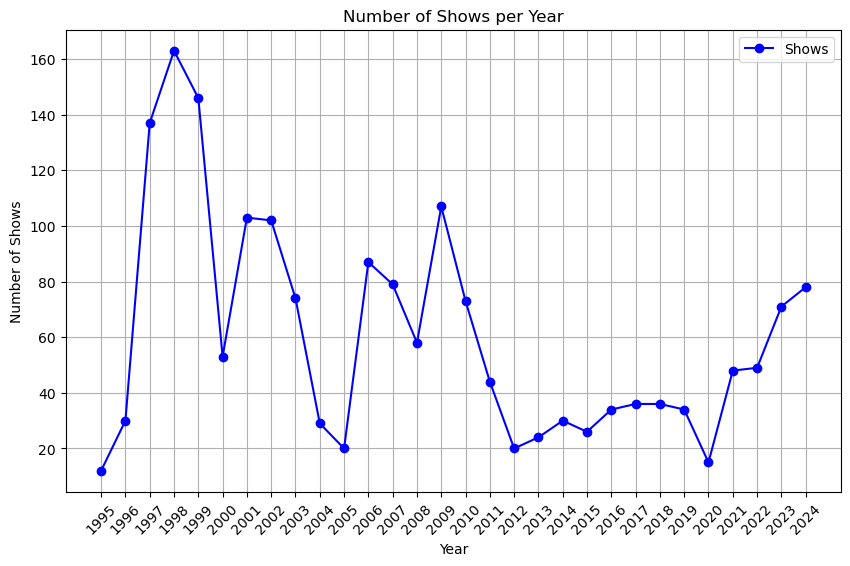

In [537]:
# import the matplotlib library to create the line graph
import matplotlib.pyplot as plot

# Create a line graph to show the number of shows per year
shows_per_year = shows_df['year'].value_counts().sort_index()

# We could achieve this using something as simple as
# shows_per_year.plot(kind='line', title='Number of Shows per Year', xlabel='Year', ylabel='Number of Shows')
# however this doesn't give us as much control over the line graph and its axes,
# so we will use matplotlib instead.

# Create the line graph
plot.figure(figsize=(10, 6))
plot.plot(shows_per_year.index, shows_per_year.values, marker='o', linestyle='-', color='blue', label='Shows')
plot.title('Number of Shows per Year')
plot.xlabel('Year')
plot.ylabel('Number of Shows')
plot.legend()
plot.xticks(ticks=shows_per_year.index, labels=shows_per_year.index, rotation=45)  # Set all years as labels
plot.grid(True)
plot.show()

### New song introductions by year
Next, we'd like to explore the rate at which the band has produced new songs.  Because the songs dataset does not contain a column indicating when the song was first played, we must instead gather this information by joining the songs and tracks data, along with the show data.

In [538]:
# Merge tracks with shows to get the date and year of each track's performance
tracks_shows_merged = tracks_df.merge(shows_df, left_on='show_id', right_on='id', how='inner')

# Merge the resulting DataFrame with songs to get the song titles and IDs.  We only care about original songs for this analysis
complete_data = tracks_shows_merged.merge(original_songs_df, left_on='song_id', right_on='id', how='inner')

# Find the first year each song was played by grouping by song and finding the earliest year
songs_first_played_year = (
    complete_data.groupby('song_id', as_index=False)
    .agg({'year': 'min'})
    .rename(columns={'year': 'first_played_year'})
)

songs_first_played_counts = (
    songs_first_played_year.groupby('first_played_year', as_index=False)
    .size()
    .rename(columns={'first_played_year': 'year', 'size': 'number_of_songs'})
    .sort_values(by='year')
)

songs_first_played_counts

,year,number_of_songs
0,1995,18
1,1996,11
2,1997,14
3,1998,23
4,1999,12
5,2000,24
6,2001,19
7,2002,14
8,2003,18
9,2004,2


We can use the matplotlib library to create a line graph of the data for each year to visually show the rate of new song introduction

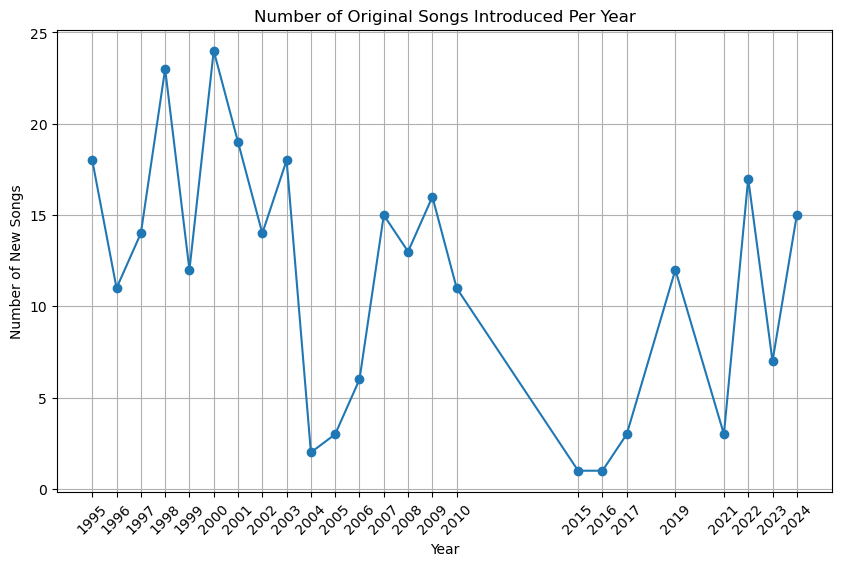

In [539]:
# Create a line graph for the number of songs first played each year
plot.figure(figsize=(10, 6))
plot.plot(songs_first_played_counts['year'], songs_first_played_counts['number_of_songs'], marker='o', linestyle='-')
plot.title('Number of Original Songs Introduced Per Year')
plot.xlabel('Year')
plot.ylabel('Number of New Songs')
plot.xticks(ticks=songs_first_played_counts['year'], labels=songs_first_played_counts['year'], rotation=45)  # Set all years as labels
plot.grid(True)
plot.show()

The data above shows us the frequency of new songs being introduced, and revels some interesting information.  There is a notable gap between 2010 and 2015, where the band was going through a period of upheaval and internal discord.  Tensions were high between band members, and the guitarist, Jon "Barber" Gutwillig, suffered a broken wrist in 2010 after punching a paper towel dispenser in frustration after a particularly unsatisfactory show performance.  Determined to continue touring, the band needed to work around this by initially playing with only 3 members (in a period known as "The Triscuits"), and eventually fill in with a guest guitarist, Tom Hamilton. Eventually, however, the band returned to normal relations, and rediscovered their love of creating new music together.

Additionally, there is another gap between 2019 and 2021, while the band (along with the rest of the world) sheltered in place for the COVID-19 lockdown.

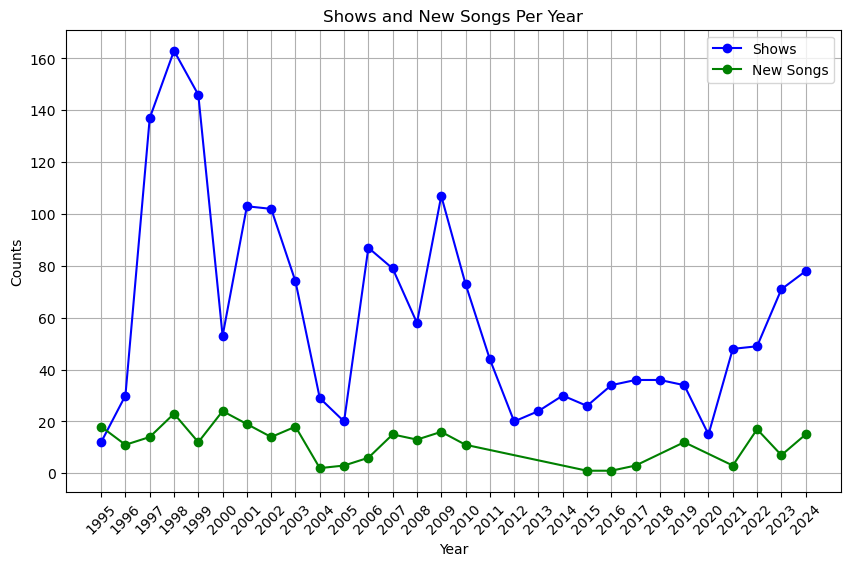

In [540]:
# Create a new figure
plot.figure(figsize=(10, 6))

# Plot the number of shows per year
plot.plot(shows_per_year.index, shows_per_year.values, marker='o', linestyle='-', color='blue', label='Shows')

# Plot the number of original songs introduced per year
plot.plot(songs_first_played_counts['year'], songs_first_played_counts['number_of_songs'], 
         marker='o', linestyle='-', color='green', label='New Songs')

# Add titles and labels
plot.title('Shows and New Songs Per Year')
plot.xlabel('Year')
plot.ylabel('Counts')

# Customize x-axis ticks
plot.xticks(
    ticks=sorted(set(shows_per_year.index).union(set(songs_first_played_counts['year']))),  # Combined unique years
    rotation=45
)

# Include a legend to explain what the lines are
plot.legend()

# Add a grid for better readability
plot.grid(True)

# Show the plot
plot.show()


### Tour performances by state and region
We want to investigate where the Disco Biscuits have toured the most.  Being that
they originated in Philladelphia, PA.

Our states data frame contains information about the 50 U.S. states, inculding
their 2 letter code, region and subdivision.

In [541]:
states_df_preview = states_df.head(4)
states_df_preview

,State,State Code,Region,Division
0,Alaska,AK,West,Pacific
1,Alabama,AL,South,East South Central
2,Arkansas,AR,South,West South Central
3,Arizona,AZ,West,Mountain


In [542]:
shows_df.merge(venues_df, left_on='venue_id', right_on='id', how='inner').groupby(['state']).size().reset_index(name='Show Count').sort_values(by='Show Count', ascending=False).head(30)

,state,Show Count
38,NY,303
43,PA,270
5,CO,136
4,CA,86
23,MA,72
35,NJ,64
32,NC,64
24,MD,61
15,IL,56
52,VA,54


In [543]:
shows_with_states_df = shows_df.merge(venues_df, left_on='venue_id', right_on='id', how='inner').merge(states_df, left_on='state', right_on='State Code', how='left')
# for shows outside the US, fill in the Region and Division as 'Other'
shows_with_states_df['Region'] = shows_with_states_df['Region'].fillna(shows_with_states_df['state'])
shows_with_states_df['Division'] = shows_with_states_df['Division'].fillna('N/A')

shows_with_states_df.groupby(['Region', 'Division']).size().reset_index(name='Show Count').sort_values(by='Show Count', ascending=False)

,Region,Division,Show Count
9,Northeast,Middle Atlantic,637
14,South,South Atlantic,351
10,Northeast,New England,193
18,West,Mountain,182
7,Midwest,East North Central,131
19,West,Pacific,109
13,South,East South Central,66
15,South,West South Central,50
8,Midwest,West North Central,30
6,Mexico,N/A,15


We can visualize the frequency of playing in any given US state by importing the plotly library and creating a heatmap with its "chloropleth" function.

In [544]:
# use plotly to visualize state data.  Reference:
#  https://www.geeksforgeeks.org/choropleth-maps-using-plotly-in-python/#
#  https://plotly.com/python/choropleth-maps/
import plotly.express as px

# Group by state and count the number of shows
state_counts = shows_with_states_df.groupby('state').size().reset_index(name='show_count')

# Create the choropleth map
chloro = px.choropleth(
    state_counts,
    locations='state',  # Column containing 2-letter state codes
    locationmode='USA-states',  # Map mode for US states
    color='show_count',  # Column to color code by
    scope='usa',  # Restrict to USA map
    title="Number of Shows per State (all-time)",
    color_continuous_scale='reds', # see https://plotly.com/python/builtin-colorscales/
    labels={'show_count': 'Show Count'}  # Label for the color legend
)
# disable scrolling/zooming.  See https://community.plotly.com/t/map-graph-disable-scrollzoom-drag/9664/4
chloro.layout.dragmode=False

# Show the map
chloro.show()


Let's take a look at how the show frequency per state has changed over time.  To do this we can create a chloropleth animation displaying the show data grouped by state and year

In [545]:
# Ensure the 'date' column is converted to datetime if not already
shows_with_states_df['date'] = pd.to_datetime(shows_with_states_df['date'])

# Extract the year from the 'date' column
shows_with_states_df['year'] = shows_with_states_df['date'].dt.year

# Group by state and year to count the number of shows in each state for each year
state_year_counts = shows_with_states_df.groupby(['state', 'year']).size().reset_index(name='show_count')

# Sort the dataframe by year in ascending order to ensure the animation is in chronological order
state_year_counts_sorted = state_year_counts.sort_values(by='year')


# Determine the overall range for the color scale, this way the color scale is
# consistent across all frames instead of varying in scale from frame to frame
min_show_count = state_year_counts_sorted['show_count'].min()
max_show_count = state_year_counts_sorted['show_count'].max()

# Create the animated choropleth map
chloro = px.choropleth(
    state_year_counts_sorted,
    locations='state',  # Column with state codes (e.g., 'CA', 'NY')
    locationmode='USA-states',  # Map mode for US states
    color='show_count',  # Column to color code by
    hover_name='state',  # Column for hover text
    animation_frame='year',  # Column for animation frames (years)
    scope='usa',  # Restrict to USA map
    title="Number of Shows per State Over Time",
    color_continuous_scale='reds',
    labels={'show_count': 'Show Count'}, # Label for the color legend
    range_color=[min_show_count, max_show_count] # Fixed color range

)

# slow down the animation speed a bit.
# See https://community.plotly.com/t/how-to-slow-down-animation-in-plotly-express/31309/6
chloro.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 1000
# disable scrolling/zooming.  See https://community.plotly.com/t/map-graph-disable-scrollzoom-drag/9664/4
chloro.layout.dragmode=False

# Show the animated map
chloro.show()
